In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="ticks", palette="pastel")

# Seed for reproducibility
np.random.seed(101)

data_size = 1000

# 1. Generate 'Marketing Spend' (Normal Distribution)
marketing_spend = np.random.normal(loc=5000, scale=1500, size=data_size)

# 2. Generate 'Sales' based on Marketing Spend (Positive Correlation) + Random Noise
# Sales = 3 * Marketing + Noise
sales = (marketing_spend * 3) + np.random.normal(loc=0, scale=2000, size=data_size)

# 3. Generate 'Customer Satisfaction' (Skewed Data, limited 1-10)
satisfaction = np.random.beta(a=7, b=2, size=data_size) * 10

# 4. Generate 'Region' (Categorical)
regions = np.random.choice(['North', 'South', 'East', 'West'], size=data_size)

# Create DataFrame
df = pd.DataFrame({
    'Marketing_Spend': marketing_spend,
    'Sales': sales,
    'Satisfaction': satisfaction,
    'Region': regions
})

# 5. INTRODUCE OUTLIERS MANUALLY
# Let's add 5 entries with massive Sales but low Marketing spend (Anomalies)
outliers = pd.DataFrame({
    'Marketing_Spend': [500, 600, 450, 550, 500],
    'Sales': [40000, 42000, 39000, 45000, 41000], # Huge sales
    'Satisfaction': [2, 1, 2, 1, 3],
    'Region': ['North'] * 5
})

df = pd.concat([df, outliers], ignore_index=True)

print(f"✅ Complex Dataset Created with {len(df)} rows.")
df.tail()

✅ Complex Dataset Created with 1005 rows.


,Marketing_Spend,Sales,Satisfaction,Region
1000,500.0,40000.0,2.0,North
1001,600.0,42000.0,1.0,North
1002,450.0,39000.0,2.0,North
1003,550.0,45000.0,1.0,North
1004,500.0,41000.0,3.0,North


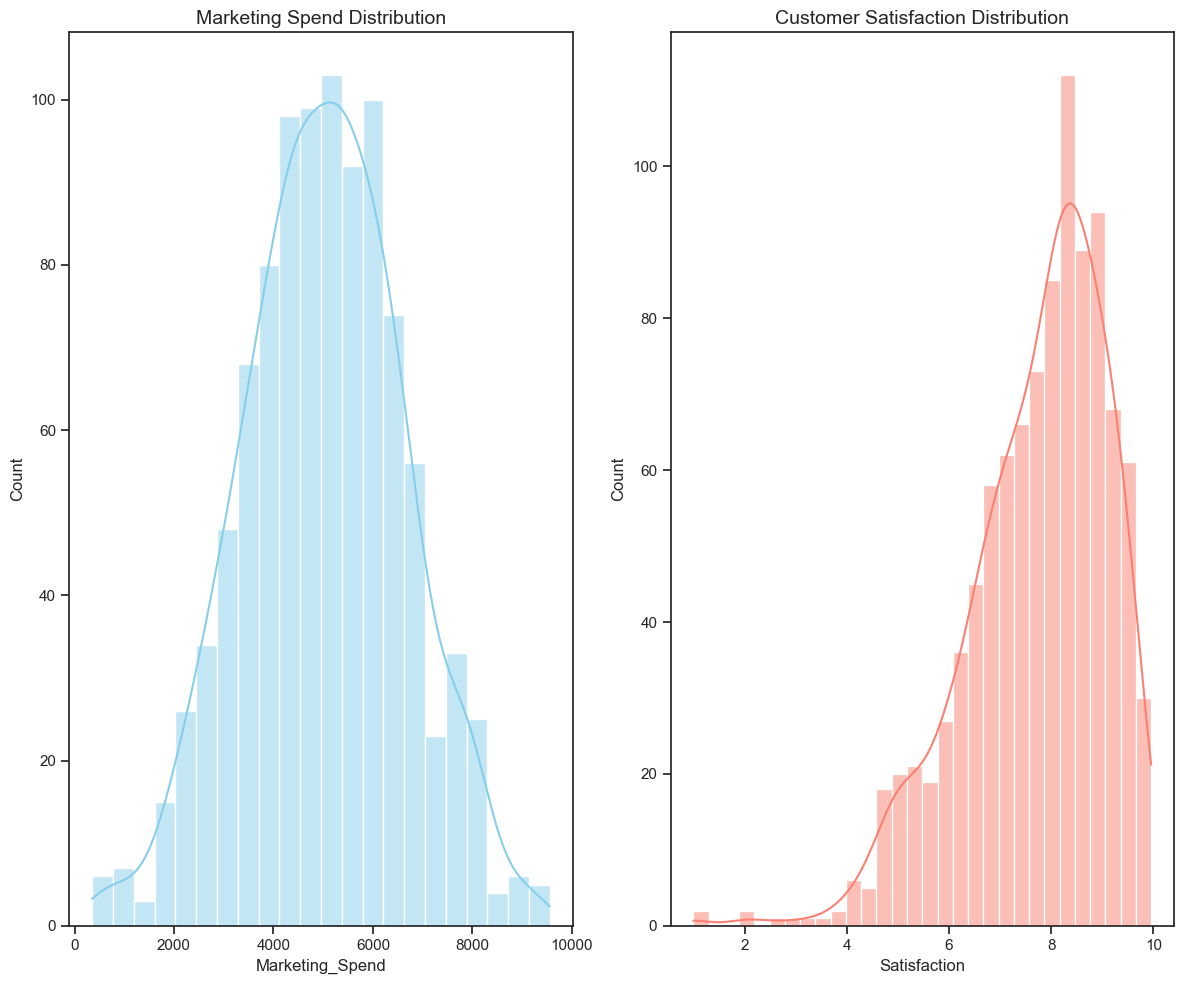

✅ Histograms Plotted.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 10))

sns.histplot(df['Marketing_Spend'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Marketing Spend Distribution', fontsize=14)

sns.histplot(df['Satisfaction'], kde=True, bins=30, ax=axes[1], color='salmon')
axes[1].set_title('Customer Satisfaction Distribution', fontsize=14)
plt.tight_layout()
plt.show()

print(f"✅ Histograms Plotted.")

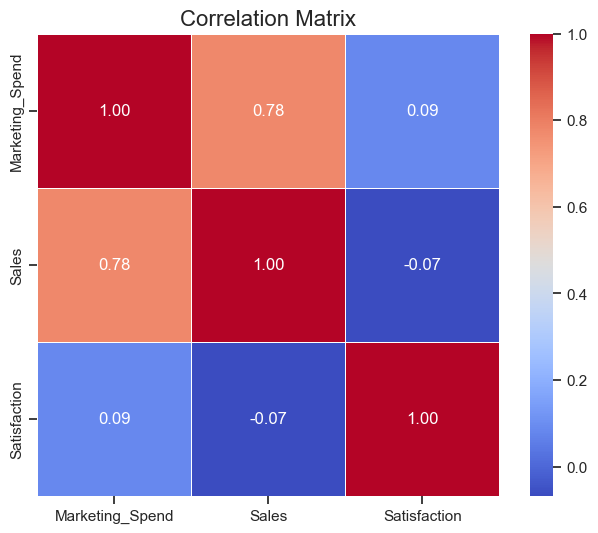

In [6]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5)

plt.title('Correlation Matrix', fontsize=16)
plt.show()

/var/folders/pc/qpl83vwd53v_hm0hj90d3nz00000gn/T/ipykernel_24181/2165543731.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y='Sales', data=df, palette='Set2')


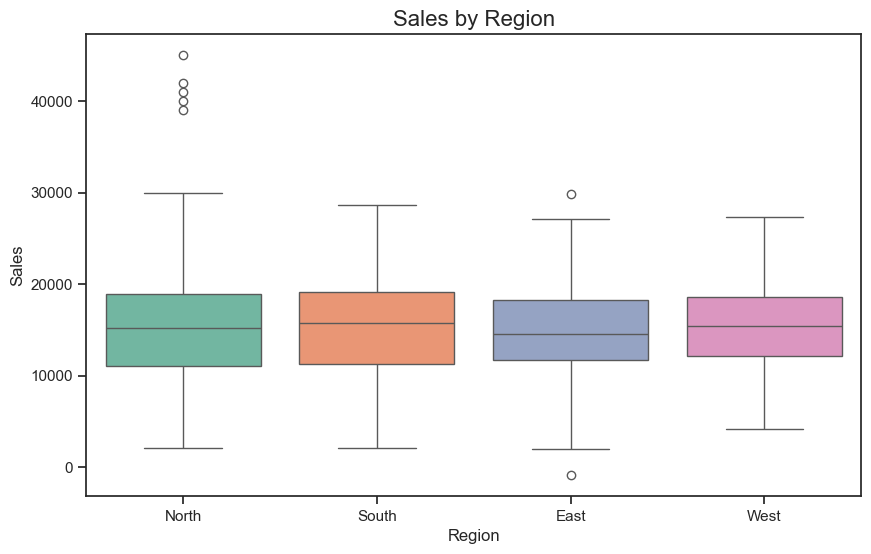

In [7]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='Region', y='Sales', data=df, palette='Set2')
plt.title('Sales by Region', fontsize=16)
plt.show()

In [8]:
def remove_outliers(data, columns):
    Q1 = data[columns].quantile(0.25)
    Q3 = data[columns].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return data[(data[columns] >= lower_bound) & (data[columns] <= upper_bound)]
    return clean_data